In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import skimage
from skimage.exposure import match_histograms

In [2]:
def show_colour_histogram(img, title):
    plt.figure(figsize=(12, 6))
    for i, color in enumerate(['b', 'g', 'r']):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        # Normalizar el histograma
        hist = cv2.normalize(hist, hist).flatten()
        #plt.plot(hist, color=color)
        plt.bar(range(256), hist.ravel(), color=color, alpha=0.6, label=f'Canal {color.upper()}')
        plt.xlim([0, 256])
        plt.ylim([0,1])
    plt.title(title)
    plt.xlabel('Intensidad de color')
    plt.ylabel('Frecuencia')
    plt.legend(['Canal B', 'Canal G', 'Canal R'])
    plt.show()

1. Calcular el histograma de una imagen en escala de grises y de cada canal de una imagen a color.
Visualizar los histogramas usando Matplotlib.

In [3]:
def show_image(image, title=None):
    """Display an image using matplotlib."""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()
    
def calc_hist(img, is_gray=False, title ='', colors=None, separate_channels=False, ylim=False):
    result = []
    plt.figure(figsize=(12, 6))
    if not is_gray and colors is None:
        colors = [['b', 'g', 'r']]
    if is_gray:
        hist = cv2.calcHist([img], [0], None, [256], [0, 256])
        plt.hist(img.ravel(), bins=256, range=[0,256])
        plt.xlim([0, 256])
        if ylim:
            plt.ylim([0,1000])
        plt.title(title)
        plt.xlabel('Intensidad de gris')
        plt.ylabel('Frecuencia')
        plt.show()
        result.append(hist)
    else:
        if separate_channels:
            for i, canal in enumerate(['h', 's', 'v']):
                plt.figure(figsize=(12, 6))
                hist = cv2.calcHist([img], [i], None, [256], [0, 256])
                plt.hist(cv2.split(img_hsv)[i].ravel(), bins=256, range=[0,256])
                plt.xlim([0, 256])
                if ylim:
                    plt.ylim([0,1000])
                plt.title(f'Histograma del canal {canal}')
                plt.xlabel(f'Intensidad de {canal}')
                plt.ylabel('Frecuencia')
                plt.show()
                result.append(hist)
        else:
            for i, color in enumerate(colors):
                hist = cv2.calcHist([img], [i], None, [256], [0, 256])
                plt.bar(range(256), hist.ravel(), color=color, alpha=0.6, label=f'Canal {color.upper()}')
                plt.xlim([0, 256])
                if ylim:
                    plt.ylim([0,1000])
                result.append(hist)
            plt.title(title)
            plt.xlabel('Intensidad de color')
            plt.ylabel('Frecuencia')
            plt.legend(['Canal B', 'Canal G', 'Canal R'])
            plt.show()
    return result

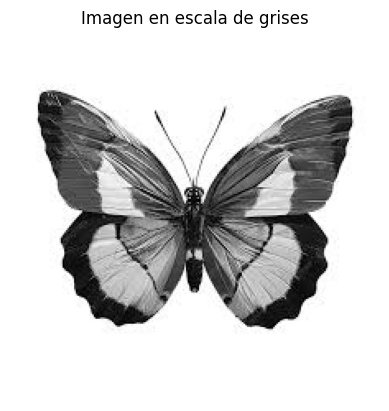

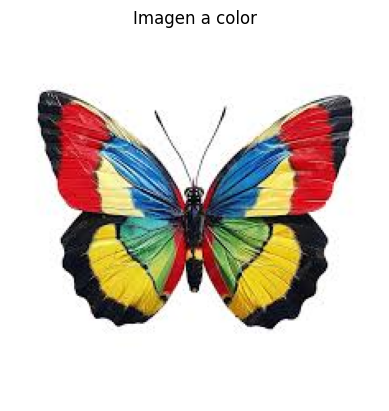

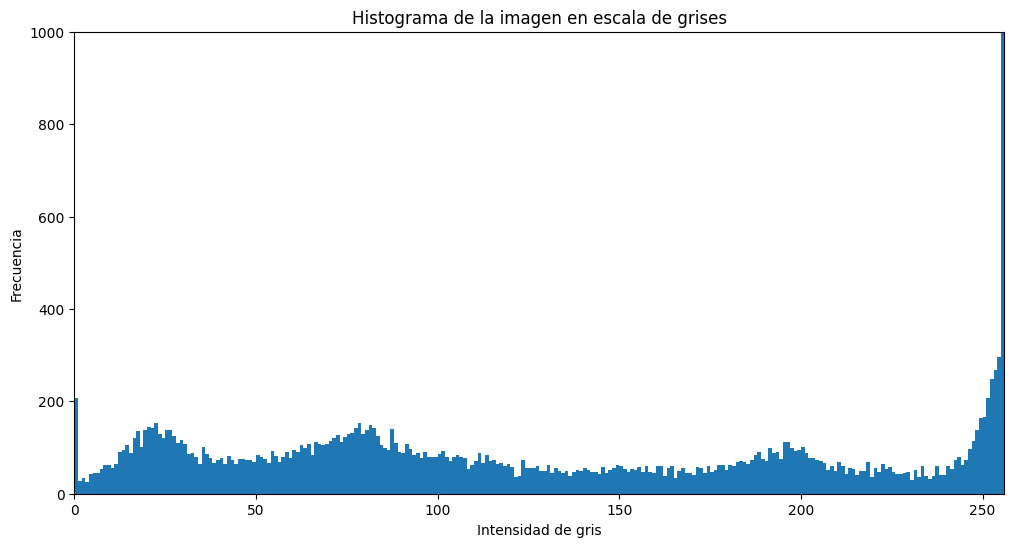

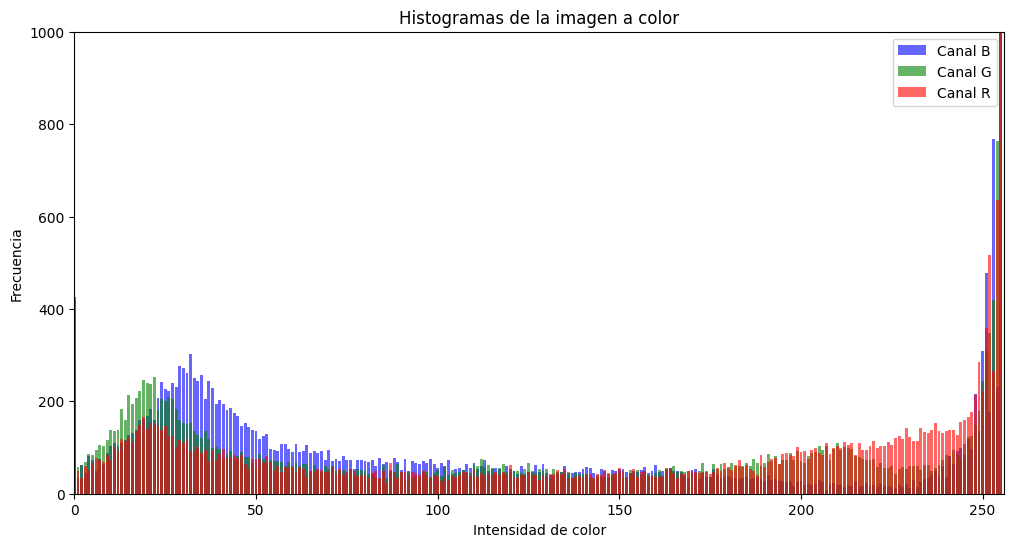

[array([[4.250e+02],
        [3.500e+01],
        [6.300e+01],
        [4.400e+01],
        [8.200e+01],
        [7.200e+01],
        [5.000e+01],
        [7.500e+01],
        [6.500e+01],
        [8.800e+01],
        [1.040e+02],
        [1.090e+02],
        [1.030e+02],
        [1.090e+02],
        [1.170e+02],
        [1.270e+02],
        [1.310e+02],
        [1.370e+02],
        [1.600e+02],
        [1.610e+02],
        [1.680e+02],
        [1.840e+02],
        [1.590e+02],
        [2.080e+02],
        [2.410e+02],
        [2.270e+02],
        [2.230e+02],
        [2.400e+02],
        [2.320e+02],
        [2.760e+02],
        [2.730e+02],
        [2.620e+02],
        [3.020e+02],
        [2.500e+02],
        [2.440e+02],
        [2.580e+02],
        [2.060e+02],
        [2.430e+02],
        [2.290e+02],
        [1.950e+02],
        [2.030e+02],
        [1.940e+02],
        [1.810e+02],
        [1.850e+02],
        [1.740e+02],
        [1.690e+02],
        [1.460e+02],
        [1.53

In [57]:
img_gris = cv2.imread('mariposa.jpg', cv2.IMREAD_GRAYSCALE)
img_color = cv2.imread('mariposa.jpg')


show_image(img_gris, title='Imagen en escala de grises')
show_image(img_color, title='Imagen a color')

calc_hist(img_gris, is_gray=True, title='Histograma de la imagen en escala de grises', ylim=True)
calc_hist(img_color, title='Histogramas de la imagen a color', colors=['b', 'g', 'r'], ylim=True)



2. Convertir una imagen de color a escala de grises y HSV. Extraer cada canal de color por separado y
mostrarlo con histograma.

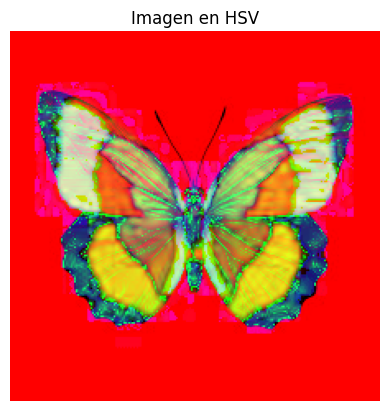

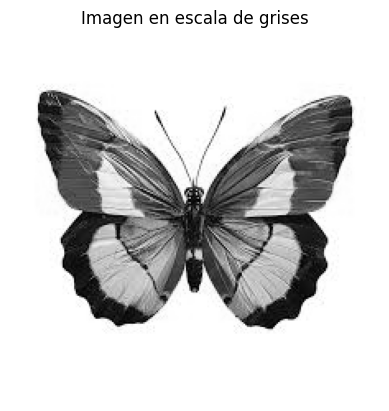

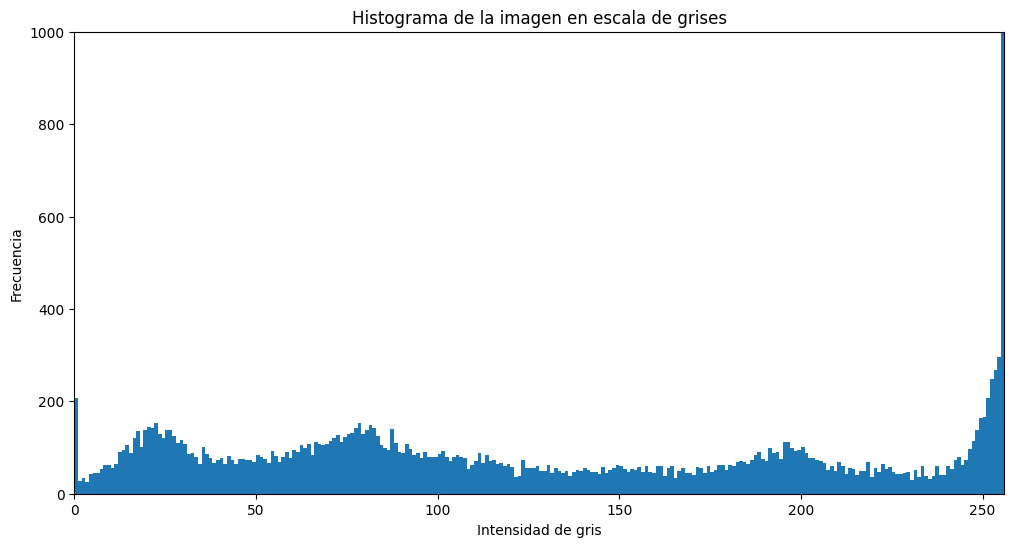

<Figure size 1200x600 with 0 Axes>

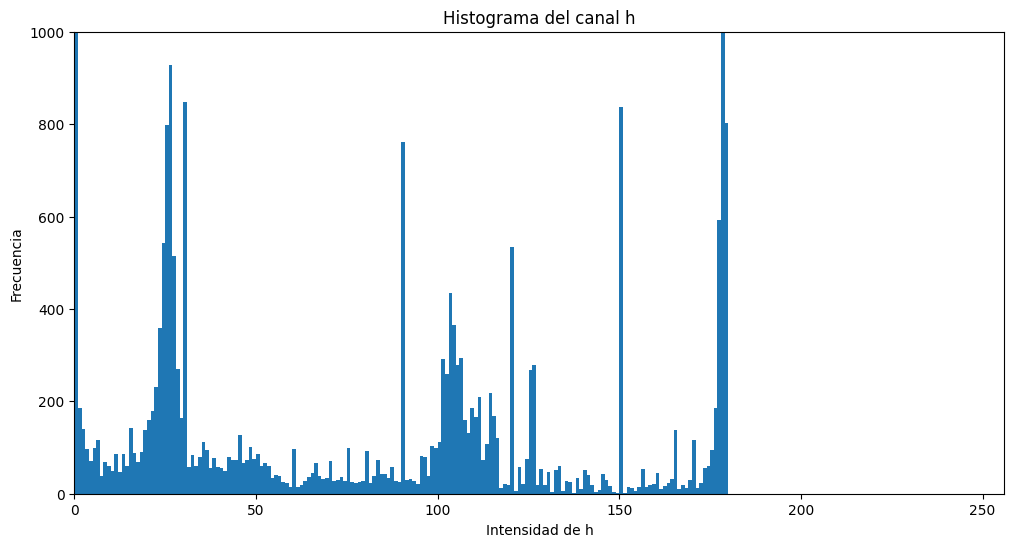

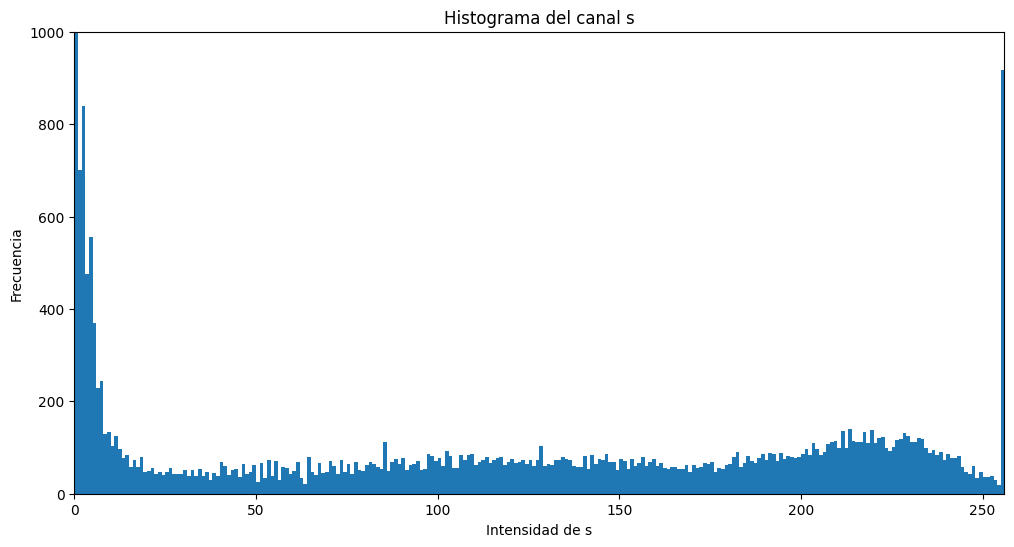

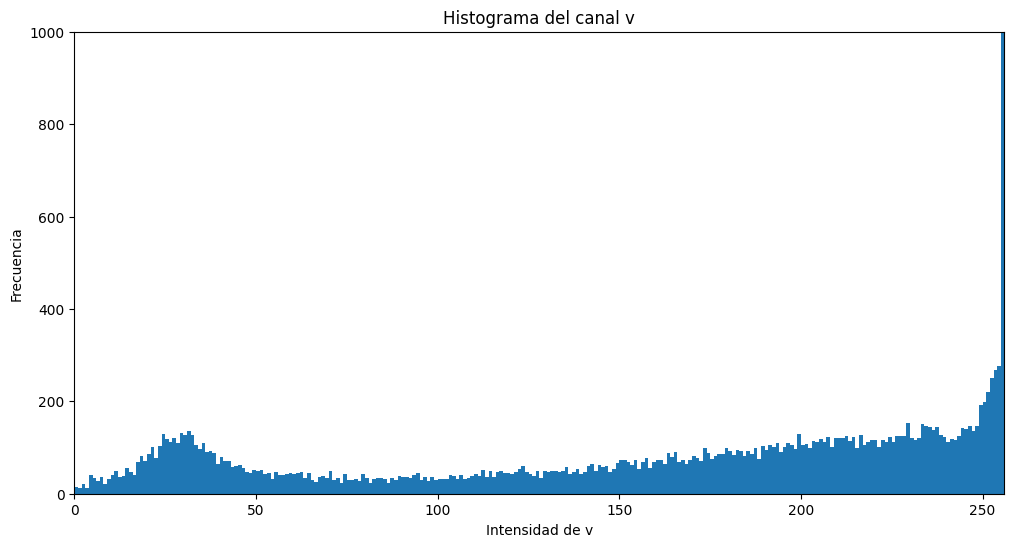

[array([[2.9364e+04],
        [1.8500e+02],
        [1.4100e+02],
        [9.7000e+01],
        [7.1000e+01],
        [9.9000e+01],
        [1.1700e+02],
        [3.9000e+01],
        [6.8000e+01],
        [5.9000e+01],
        [5.0000e+01],
        [8.7000e+01],
        [4.7000e+01],
        [8.7000e+01],
        [5.9000e+01],
        [1.4300e+02],
        [8.8000e+01],
        [6.8000e+01],
        [9.0000e+01],
        [1.3800e+02],
        [1.6000e+02],
        [1.7800e+02],
        [2.3000e+02],
        [3.5800e+02],
        [5.4200e+02],
        [7.9900e+02],
        [9.2700e+02],
        [5.1400e+02],
        [2.7000e+02],
        [1.6300e+02],
        [8.4800e+02],
        [5.8000e+01],
        [8.4000e+01],
        [6.1000e+01],
        [7.9000e+01],
        [1.1200e+02],
        [9.5000e+01],
        [5.6000e+01],
        [7.7000e+01],
        [5.8000e+01],
        [5.5000e+01],
        [4.9000e+01],
        [8.0000e+01],
        [7.4000e+01],
        [7.2000e+01],
        [1

In [ ]:
img = cv2.imread('mariposa.jpg')
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

show_image(img_hsv, 'Imagen en HSV')
show_image(img_gray, 'Imagen en escala de grises')

calc_hist(img_gris, is_gray=True, title='Histograma de la imagen en escala de grises', ylim=True)
calc_hist(img_hsv, title='Histogramas de la imagen en HSV', colors=['h', 's', 'v'], separate_channels=True, ylim=True)
    


3. Cargar una imagen en escala de grises y a color. Posteriormente, modificar un conjunto de pıxeles en
una region especıfica (por ejemplo, convertir una zona a negro). Calcular el negativo de una imagen
invirtiendo los valores de pıxeles.


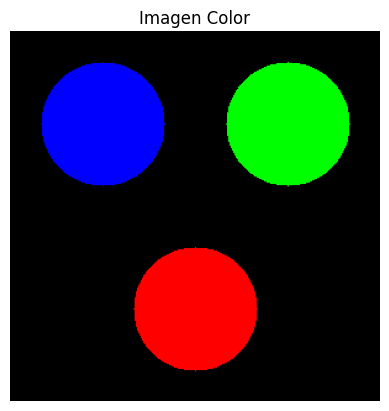

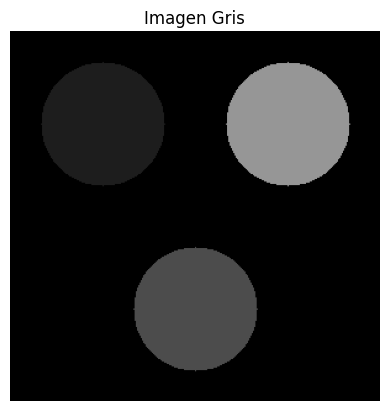

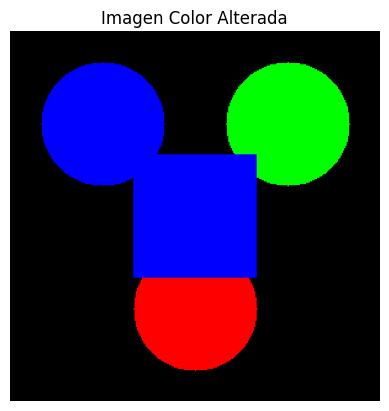

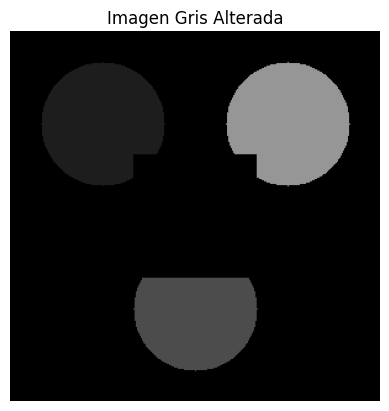

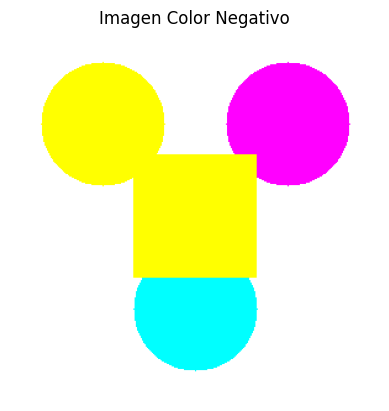

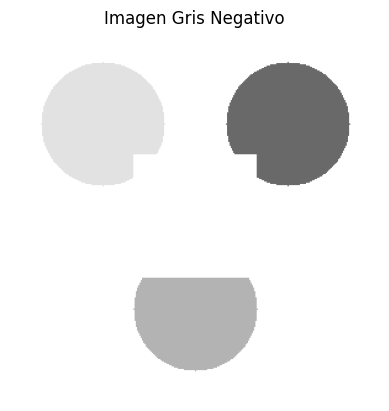

In [47]:
img = cv2.imread('img_color3.png')
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

show_image(img, 'Imagen Color')
show_image(img_gris, 'Imagen Gris')

img[100:200,100:200] = [255,0,0] # cuadrado azul
img_gris[100:200,100:200] = [0] # Cuadrado negro

show_image(img, 'Imagen Color Alterada')
show_image(img_gris, 'Imagen Gris Alterada')

img_negativo = cv2.bitwise_not(img)
img_gris_negativo = cv2.bitwise_not(img_gris)

show_image(img_negativo, 'Imagen Color Negativo')
show_image(img_gris_negativo, 'Imagen Gris Negativo')




4. Implementar una transformacion lineal de la forma I’=α I+β donde α es el factor de contraste y β
es el ajuste de brillo.

In [48]:
def ajuste_brillo_contraste(img, alfa, beta):
    img_float = img.astype(np.float32) # transformamos a float para poder tener una representacion transitoria de las operaciones
    img_ajustada = alfa * img + beta
    return np.clip(img_ajustada, 0, 255).astype(np.uint8) # clip limita los valores dentro del intervalo 0-255

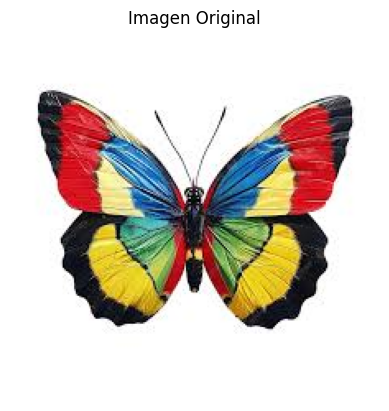

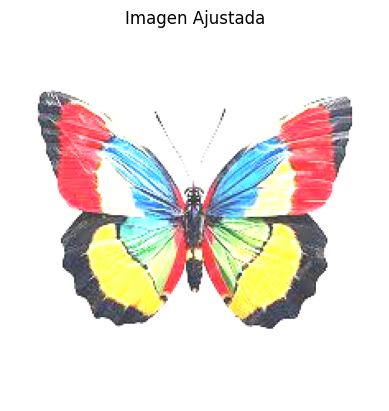

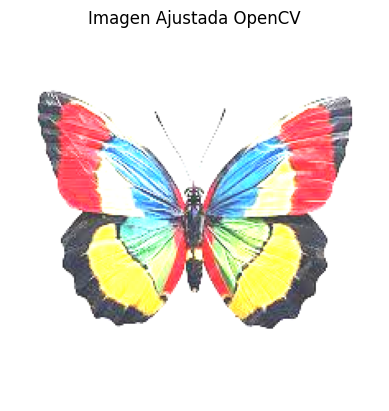

In [49]:
img = cv2.imread('mariposa.jpg')

show_image(img, 'Imagen Original')

#Version casera
img_ajustada = ajuste_brillo_contraste(img, 1.5, 50) # Aumento de contraste y brillo
show_image(img_ajustada, 'Imagen Ajustada')

#Version OpenCV
img_ajustada_opencv = cv2.convertScaleAbs(img, alpha=1.5, beta=50)
show_image(img_ajustada_opencv, 'Imagen Ajustada OpenCV')


5. Cargar dos imagenes diferentes (por ejemplo, fotos tomadas en diferentes condiciones de iluminacion).
Calcular sus histogramas y compararlos usando diferentes metricas (correlacion, chi-cuadrado, interseccion).

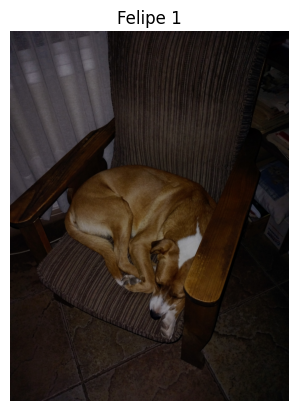

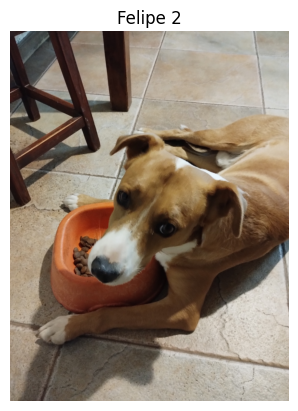

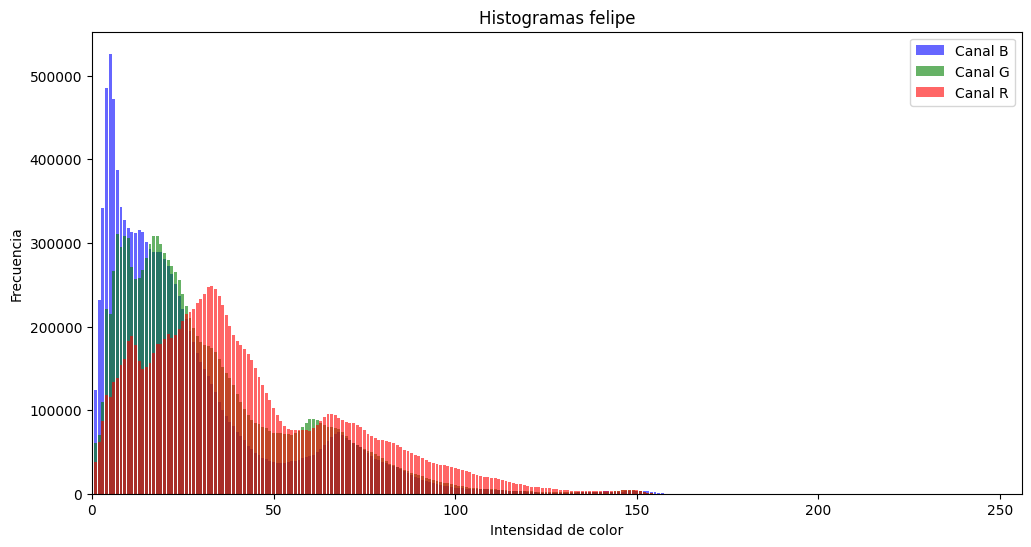

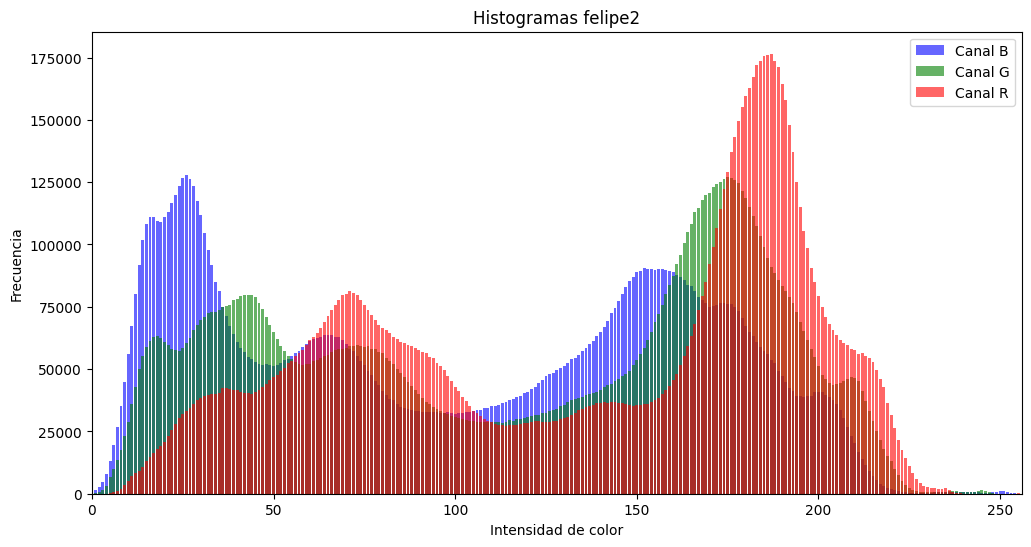

Correlacion:
  Canal b: 0.3130895322849735
  Canal g: 0.05895293922479757
  Canal r: -0.18985577054581318

Chi Cuadrado:
  Canal b: 41570.41029804824
  Canal g: 74616.2461021404
  Canal r: 63951.29740792973

Interseccion:
  Canal b: 4.566618890907193
  Canal g: 4.466269990274668
  Canal r: 4.041568183233494



In [59]:
felipe = cv2.imread('felipe.jpg')
felipe2 = cv2.imread('felipe2.jpg')

show_image(felipe, 'Felipe 1')
show_image(felipe2, 'Felipe 2')

hist_felipe = calc_hist(felipe, title='Histogramas felipe', colors=['b', 'g', 'r'])
hist_felipe2 = calc_hist(felipe2, title='Histogramas felipe2', colors=['b', 'g', 'r'])


# Normalizamos los histogramas para que tengan la misma escala (es necesario para comparar correctamente sino las fotos podrian tener distinta cantidad de pixeles)
for h1, h2 in zip(hist_felipe, hist_felipe2):
    cv2.normalize(src=h1,dst=h1)
    cv2.normalize(src=h2,dst=h2)

metodos = {
    'Correlacion': cv2.HISTCMP_CORREL,
    'Chi Cuadrado': cv2.HISTCMP_CHISQR,
    'Interseccion': cv2.HISTCMP_INTERSECT
}
resultados = {metodo: [] for metodo in metodos}

for i, canal in enumerate(['b', 'g', 'r']):
    for nombre, metodo in metodos.items():
        resultado = cv2.compareHist(hist_felipe[i], hist_felipe2[i], metodo)
        resultados[nombre].append(resultado)

for nombre, resultado in resultados.items():
    print(f'{nombre}:')
    for i, canal in enumerate(['b', 'g', 'r']):
        print(f'  Canal {canal}: {resultado[i]}')
    print()

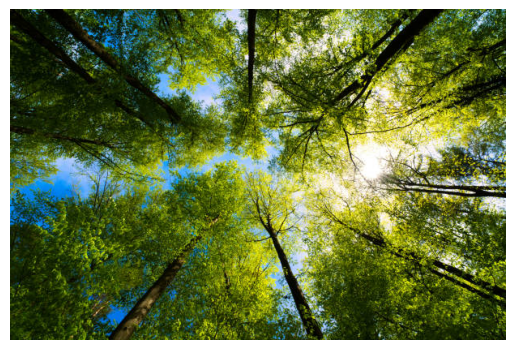

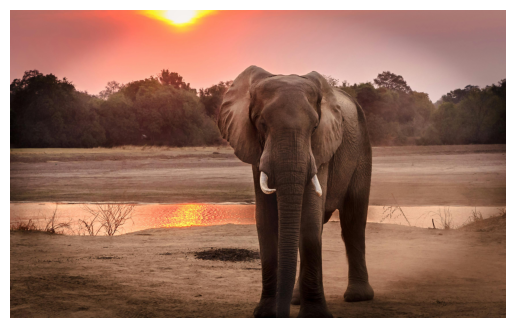

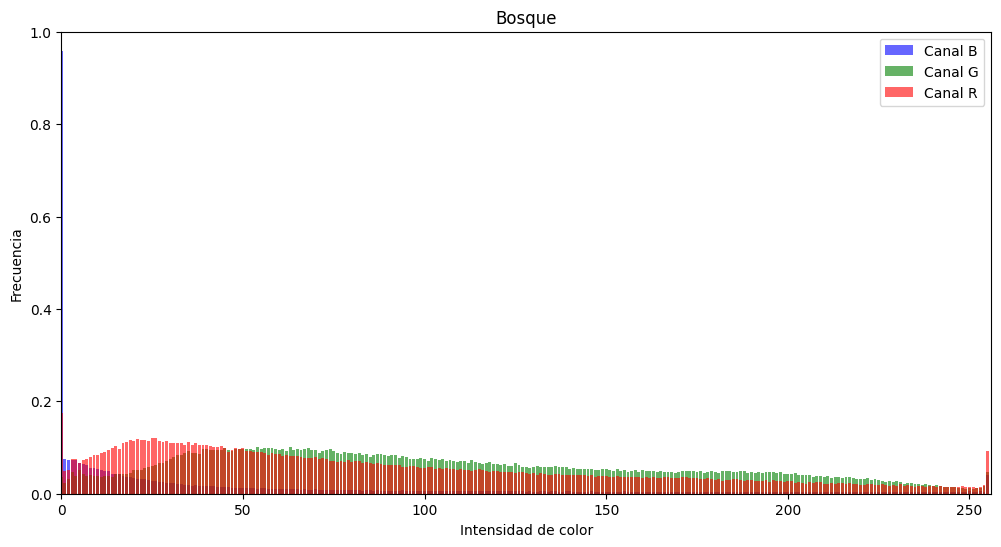

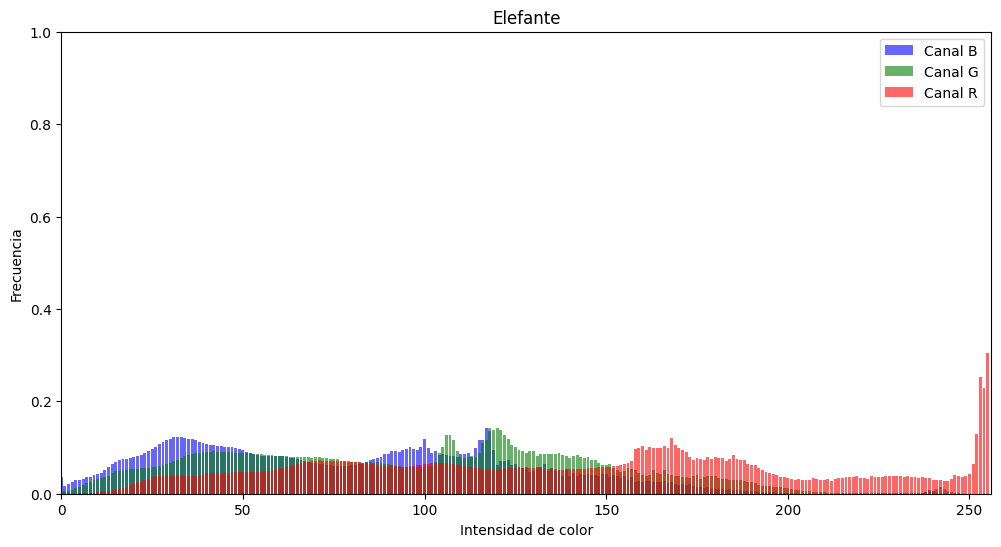

Correlación: 0.03012336411038037
Chi-cuadrado: 92.41770649437869
Intersección: 0.4639007923576912


In [51]:
img1 = cv2.imread('bosque.jpg')
img2 = cv2.imread('elefante.jpg')

# Calcular histogramas normalizados
hist1 = cv2.calcHist([img1], [0], None, [256], [0, 256])
hist2 = cv2.calcHist([img2], [0], None, [256], [0, 256])
hist1 = cv2.normalize(hist1, hist1).flatten()
hist2 = cv2.normalize(hist2, hist2).flatten()

# Comparar con distintas métricas
correl = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
chi = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CHISQR)

hist1 = cv2.normalize(hist1, hist1, norm_type=cv2.NORM_L1).flatten()
hist2 = cv2.normalize(hist2, hist2, norm_type=cv2.NORM_L1).flatten()
inter = cv2.compareHist(hist1, hist2, cv2.HISTCMP_INTERSECT)

show_image(img1)
show_image(img2)
show_colour_histogram(img1, "Bosque")
show_colour_histogram(img2, "Elefante")
print(f"Correlación: {correl}")
print(f"Chi-cuadrado: {chi}")
print(f"Intersección: {inter}")

6. Explicar que diferencias se pueden observar en los histogramas.


De acuerdo con las métricas evaluadas se observa:  
**Correlación (-1 a 1):** el valor es muy cercano a cero idicando que casi no hay correlación, los histogramas son bastante diferentes.  
**Chi-cuadrado (0 a inf.):** el valor es bastante grande, también indicando que los histogramas son distintos.  
**Intersección (0 a 1):** al igual que las métricas anteriores, indica que no hay mucha similitud entre los histogramas.


**7. (*) Transformar la distribucion de intensidades de una imagen para que se parezca a la de otra. Implementar el ajuste de histograma usando OpenCV o skimage.exposure.match histograms(). Comparar
los histogramas antes y despues del ajuste.**


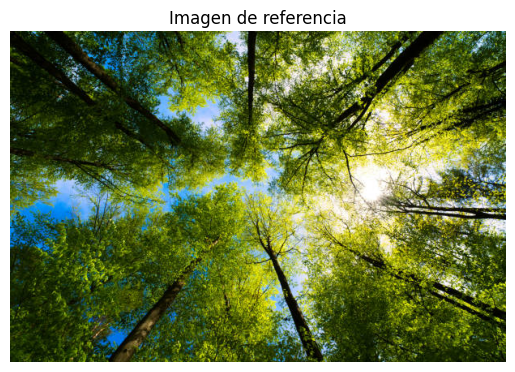

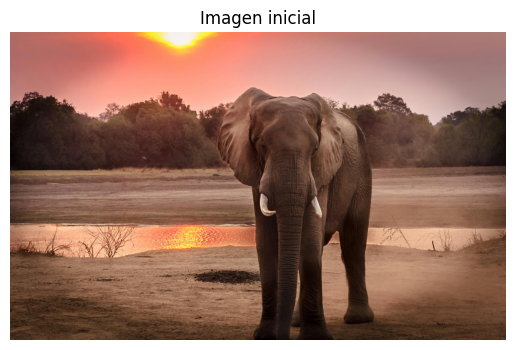

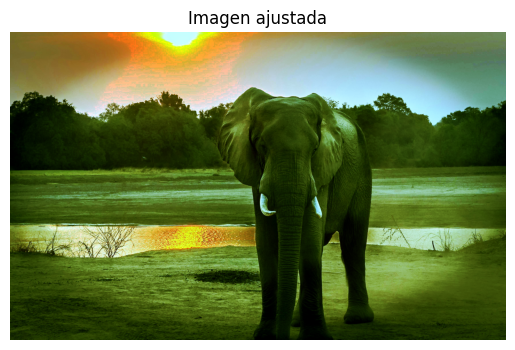

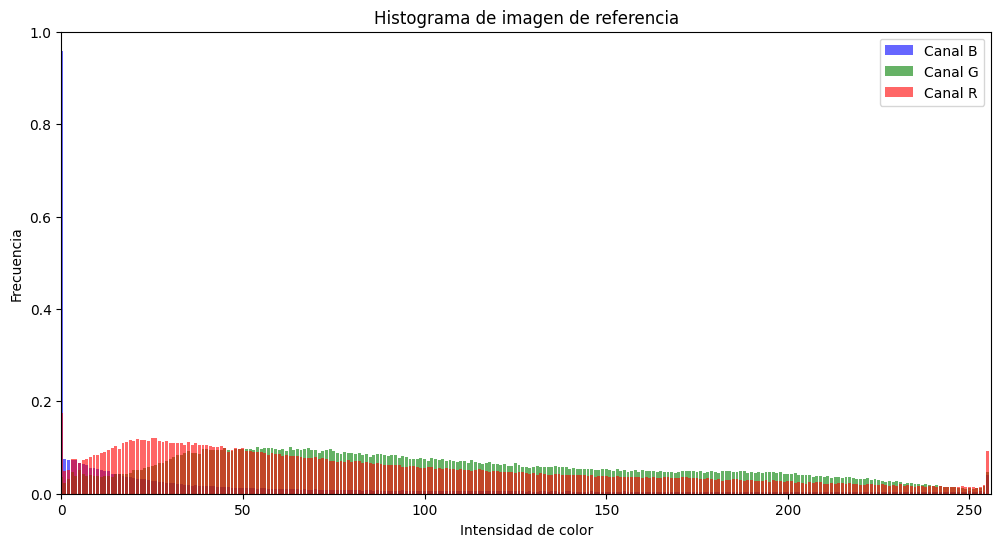

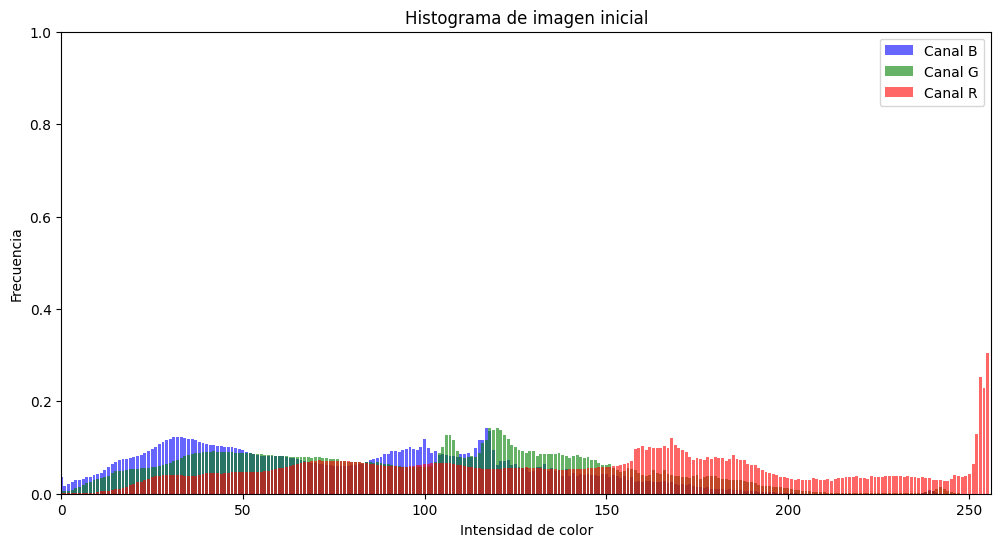

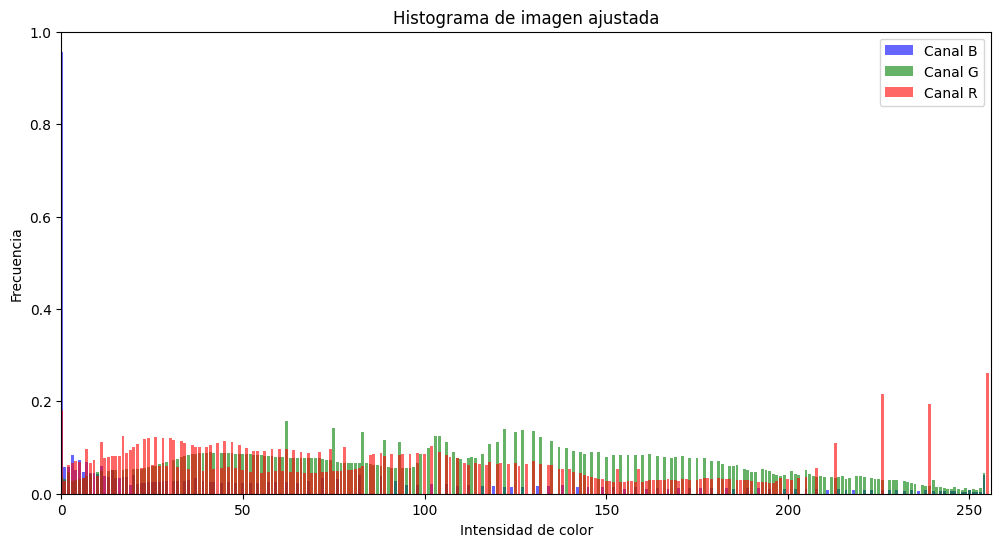

In [52]:
def match_hist_color(source, reference):
    matched = source.copy()
    for i in range(3):  # B, G, R
        matched[:,:,i] = match_histograms(source[:,:,i], reference[:,:,i])
    return matched

source = cv2.imread('elefante.jpg')
reference = cv2.imread('bosque.jpg')
matched_color = match_hist_color(source, reference)

show_image(reference, "Imagen de referencia")
show_image(source, "Imagen inicial")
show_image(matched_color,"Imagen ajustada")

pre_hist = cv2.calcHist([source], [0], None, [256], [0, 256])
post_hist = cv2.calcHist([matched_color], [0], None, [256], [0, 256])

show_colour_histogram(reference, "Histograma de imagen de referencia")
show_colour_histogram(source,"Histograma de imagen inicial")
show_colour_histogram(matched_color, "Histograma de imagen ajustada")


8. (*) Aplicar ecualizacion de histograma a una imagen en escala de grises. Comparar la imagen original
con la ecualizada.


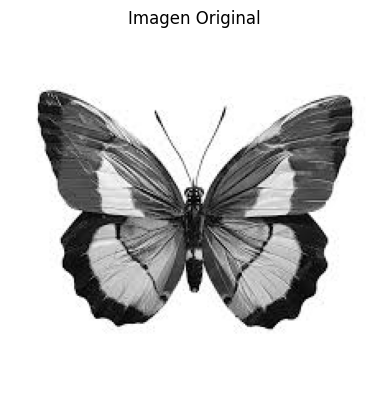

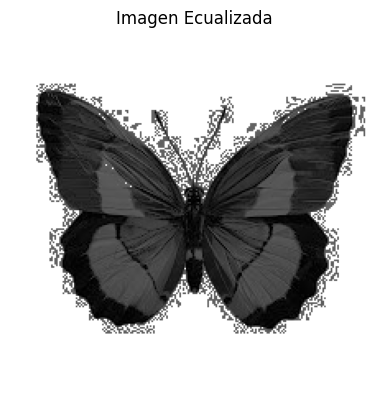

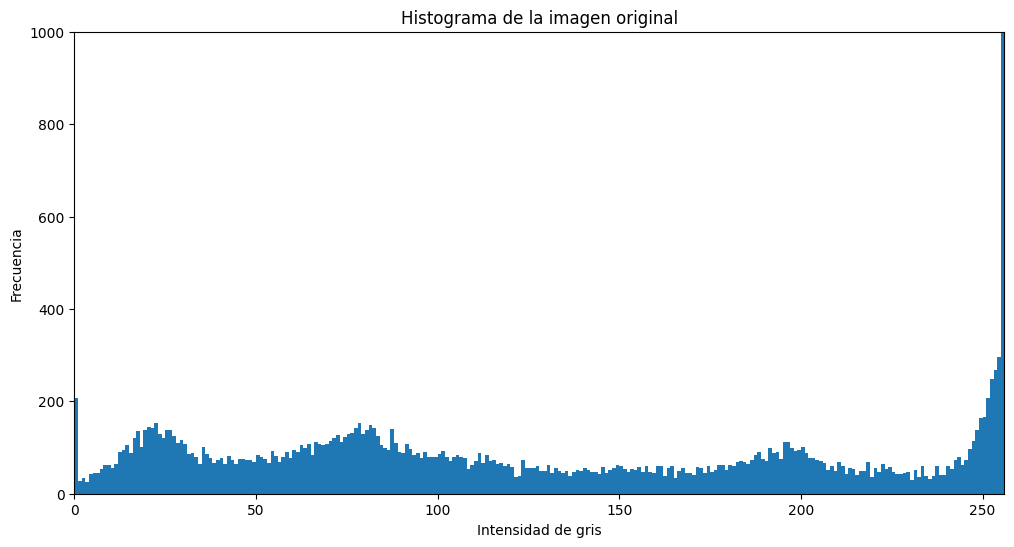

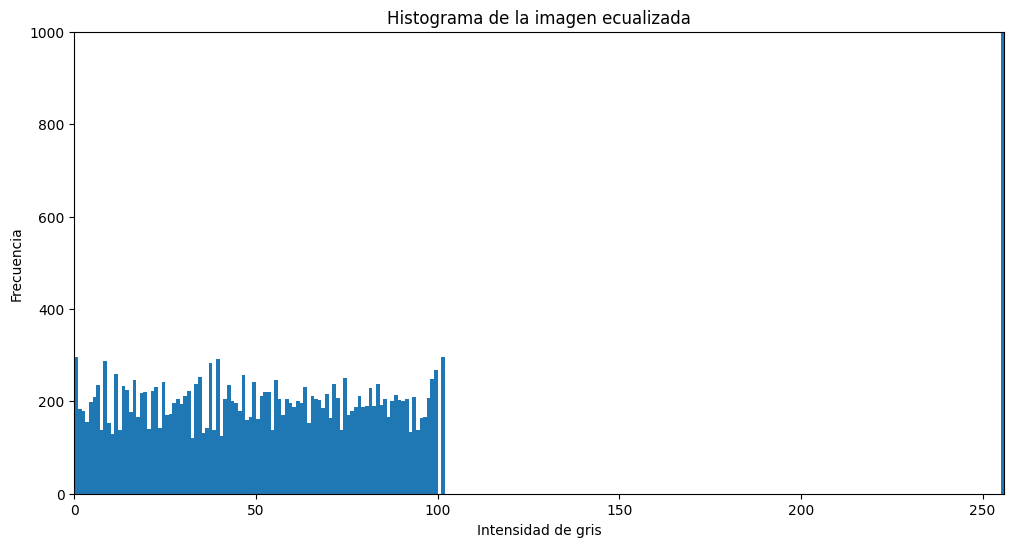

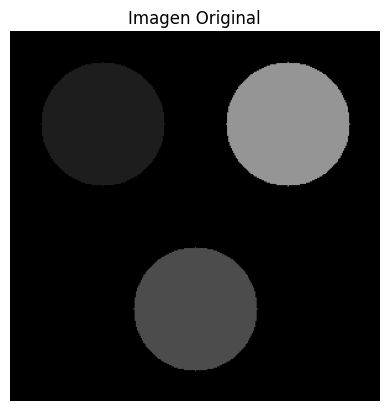

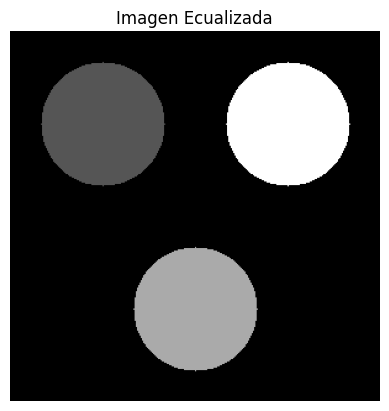

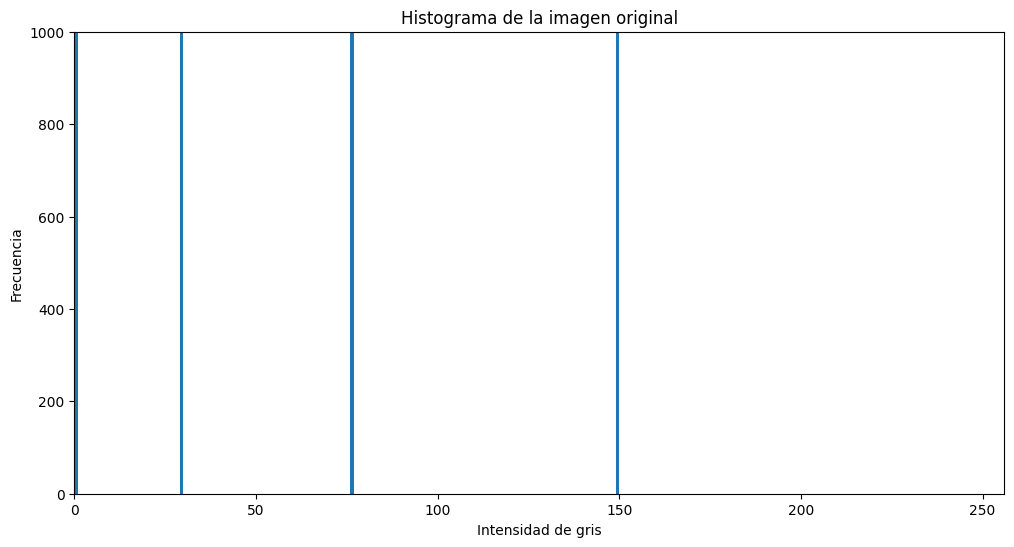

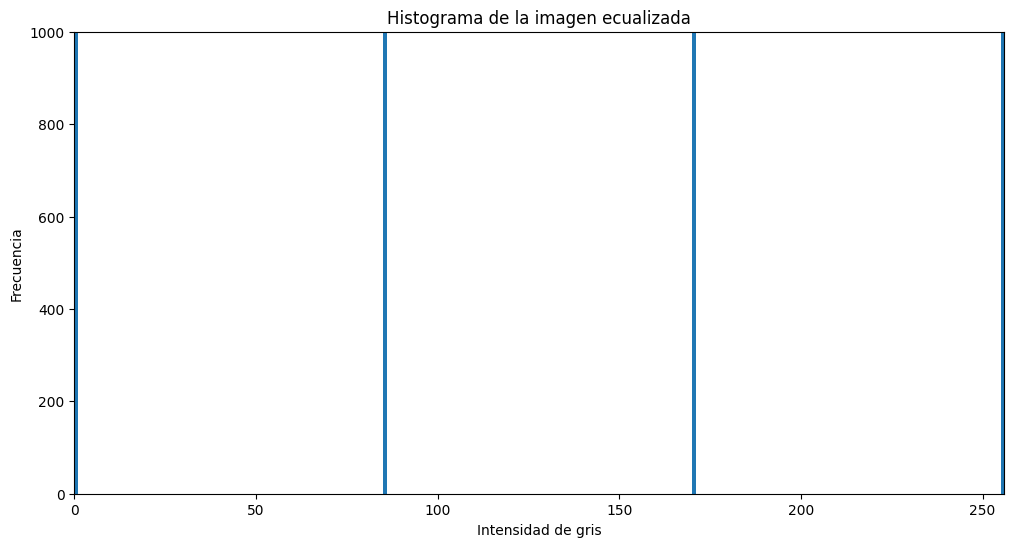

In [10]:
img = cv2.imread('mariposa.jpg', cv2.IMREAD_GRAYSCALE)
img_eq = cv2.equalizeHist(img)

show_image(img, 'Imagen Original')
show_image(img_eq, 'Imagen Ecualizada')

hist_img = calc_hist(img, is_gray=True, title='Histograma de la imagen original', ylim=True)
hist_img_eq = calc_hist(img_eq, is_gray=True, title='Histograma de la imagen ecualizada', ylim=True)

# En este caso la mariposa pierde calidad de imagen al aplicar la ecualizacion. Esto puede deberse a que la imagen de por si posee un buen balance en el histograma, sumado a que la el valor blanco en la imagen tiene una mayor representacion en el histograma, lo que tiende a dividir en 2 partes el histograma.

img2 = cv2.imread('img_color3.png', cv2.IMREAD_GRAYSCALE)
img2_eq = cv2.equalizeHist(img2)

show_image(img2, 'Imagen Original')
show_image(img2_eq, 'Imagen Ecualizada')

hist_img2 = calc_hist(img2, is_gray=True, title='Histograma de la imagen original', ylim=True)
hist_img2_eq = calc_hist(img2_eq, is_gray=True, title='Histograma de la imagen ecualizada', ylim=True)

# Al utilizar una imagen mas simple se puee observar como la ecualizacion mejora el contraste y balancea el histograma de la imagen



9. (*) Implementar una umbralizacion manual eligiendo un valor de umbral. Usar el metodo de Otsu
para calcular un umbral optimo automaticamente.

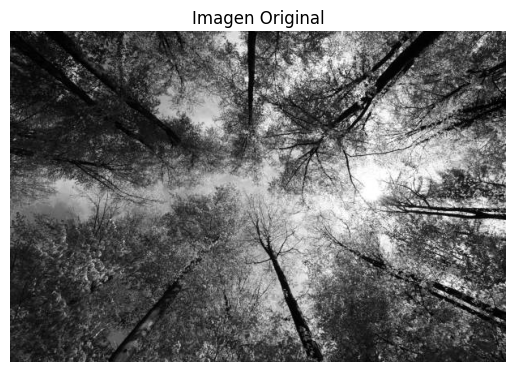

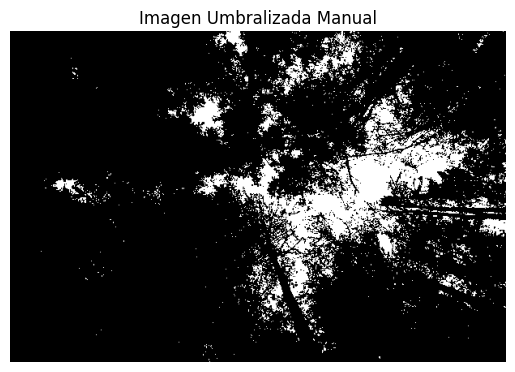

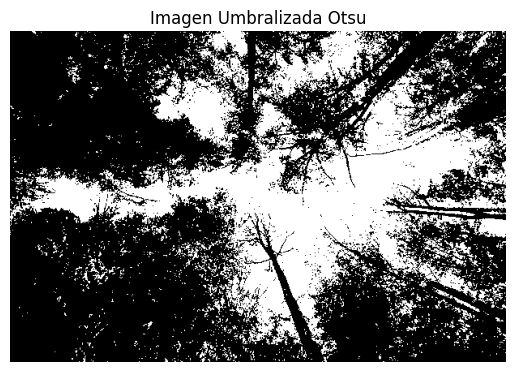

In [15]:
# Implementacion con umbralizacion manual

img = cv2.imread('bosque.jpg', cv2.IMREAD_GRAYSCALE)
umbral = 180
_, img_umbral = cv2.threshold(img, umbral, 255, cv2.THRESH_BINARY) # Devuelve el umbral y la imagen umbralizada. Devuelve -1 si no encuentra un umbral

# Implementacion con umbralizacion de Otsu

umra_otsu, img_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) 

show_image(img, 'Imagen Original')
show_image(img_umbral, 'Imagen Umbralizada Manual')
show_image(img_otsu, 'Imagen Umbralizada Otsu')

# El metodo de Otsu busca encontrar un umbral q dado que el el fondo y el objeto en el frente esten lo mas separados posibles lo que implica que tengan una varianza minima entre ambos y sus medias estan lo mas alejadas posibles (medido es el valor de intensidad)


10. Aplicar ecualizacion de histograma adaptativa (CLAHE) y analizar su efecto en imagenes con mucho
contraste.

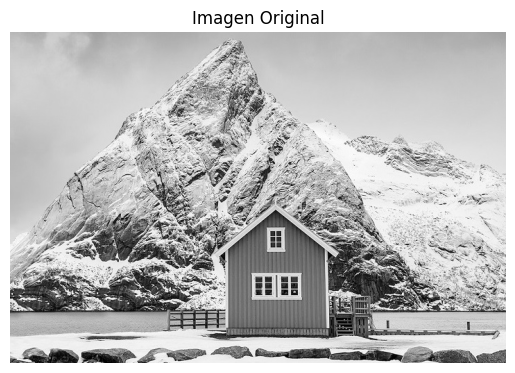

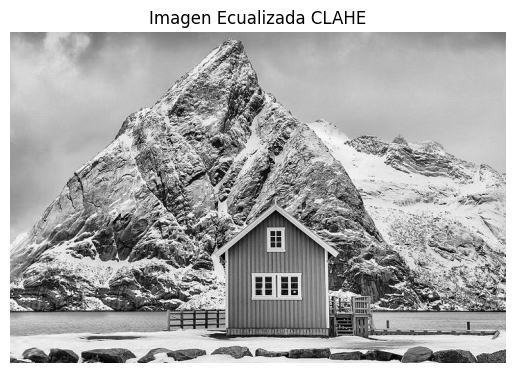

In [19]:
img = cv2.imread('contraste.jpg', cv2.IMREAD_GRAYSCALE)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)) # cliplimit controla cuanto contraste se puede amplificar. tileGridSize determina el tamaño de bloque.
img_clahe = clahe.apply(img)

show_image(img, 'Imagen Original')
show_image(img_clahe, 'Imagen Ecualizada CLAHE')

# CLAHE es una tecnica de ecualizacion que busca mejorar las ecualizaciones clasicas globales intentando evitar que ciertas partes de las imagenes se sobre saturen y que el contraste sea mejor localmente. Para ello hace uso de bloques locales (tiles) los cuales seran procesados individualmente. Tambien hace uso de un limite de contraste (clipLimit) en aquellos casos donde la region seleccionada tenga constrastes muy altos. Finalmente realiza una interpolacion entre los bordes de cada tile para suavizar los bordes de los mismos.

# Esto permite realzar los detalles mas finos de la imagen sin un perdida de calidad visible y evita que el contraste sea muy alto en ciertas regions (esto tiene un gran valor en imagenes con luz irregular).


11. (*) Implementar la transformacion gamma I’=I
y, permitiendo ajustar el valor de y dinamicamente.
Aplicar diferentes valores de y en distintas regiones de la imagen (por ejemplo, usando una mascara 
o adaptando y en funcion del brillo local). Visualizar el efecto de la correccion gamma en la imagen
y en su histograma.

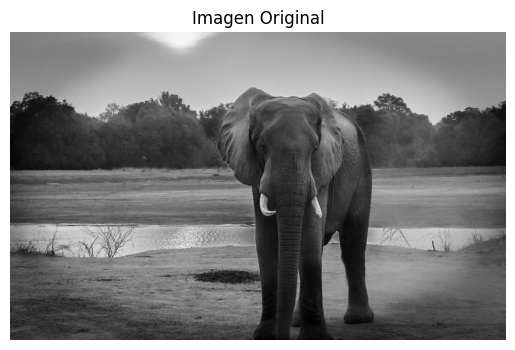

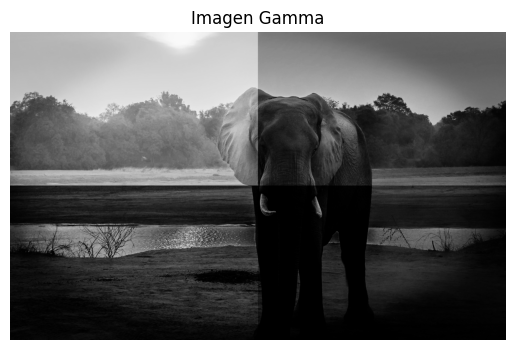

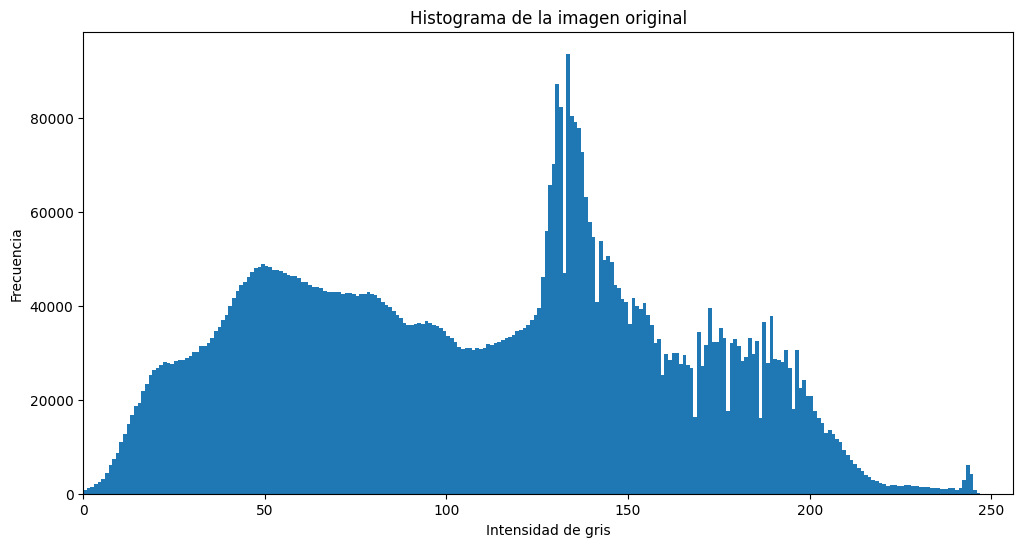

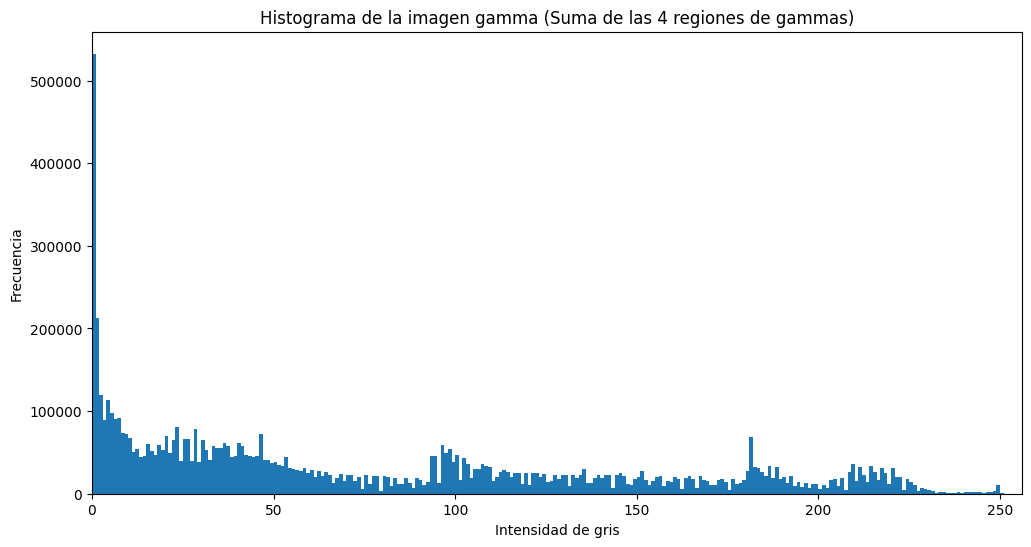

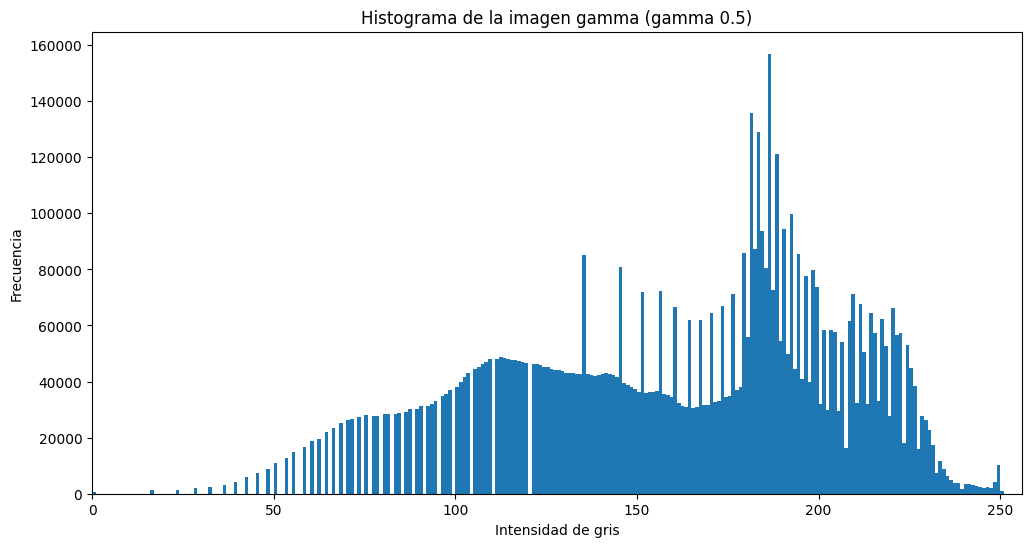

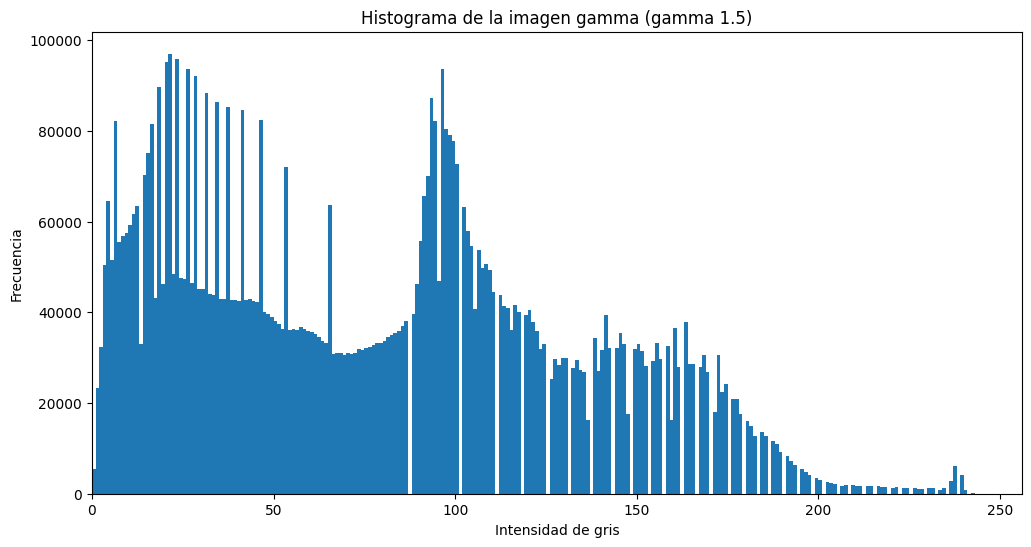

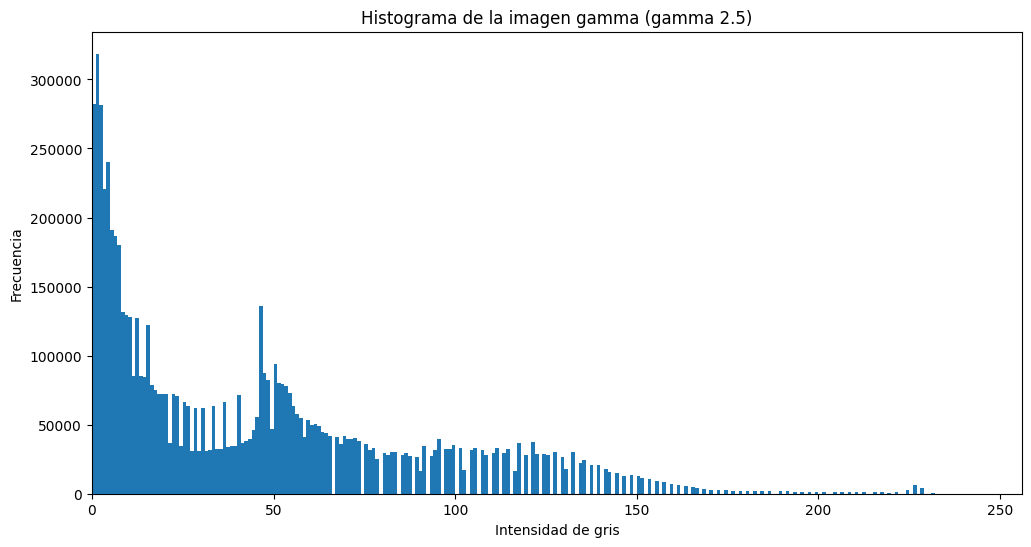

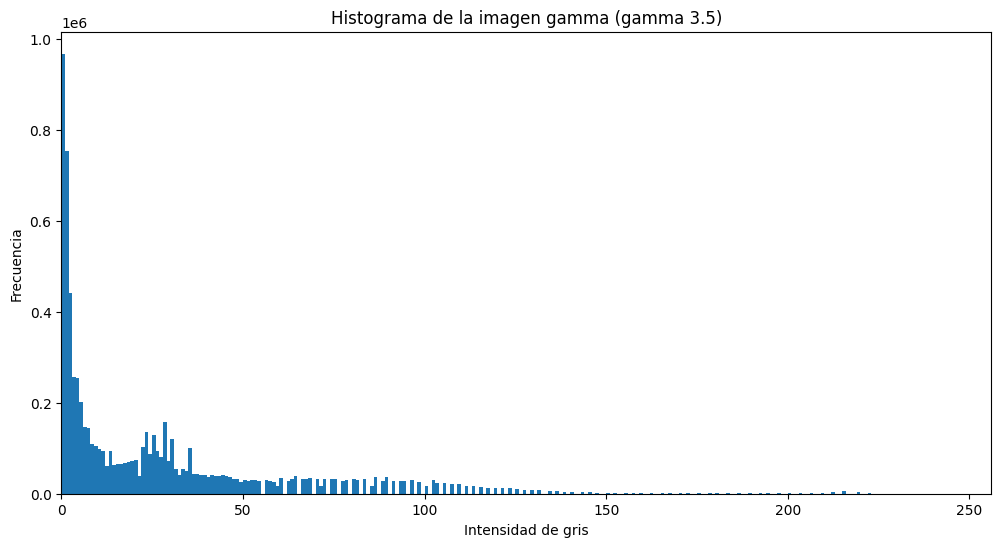

[array([[9.67054e+05],
        [7.53296e+05],
        [4.41302e+05],
        [2.56151e+05],
        [2.54924e+05],
        [2.00972e+05],
        [1.47632e+05],
        [1.44580e+05],
        [1.08846e+05],
        [1.05532e+05],
        [9.90970e+04],
        [9.31920e+04],
        [6.17260e+04],
        [9.28490e+04],
        [6.33760e+04],
        [6.44140e+04],
        [6.58810e+04],
        [6.69910e+04],
        [6.94330e+04],
        [7.12810e+04],
        [7.50670e+04],
        [3.95780e+04],
        [1.02018e+05],
        [1.35719e+05],
        [8.72370e+04],
        [1.29100e+05],
        [9.36230e+04],
        [8.04750e+04],
        [1.56930e+05],
        [7.26720e+04],
        [1.21097e+05],
        [5.46170e+04],
        [4.08150e+04],
        [5.37310e+04],
        [4.97620e+04],
        [9.99060e+04],
        [4.44010e+04],
        [4.38710e+04],
        [4.14710e+04],
        [4.08800e+04],
        [3.60610e+04],
        [4.16320e+04],
        [3.99830e+04],
        [3.

In [35]:
def gamma_correction(img, gamma=2.8):
    val_max = 256
    intensidad_max = val_max - 1
    tabla_trans = np.zeros((val_max,), dtype=np.uint8) 
    
    for intensidad in range(val_max):
        val_escala = (intensidad / intensidad_max) # Escalamos al intervalo [0,1]
        val_trans = np.power(val_escala, gamma) # Aplicamos la transformacion gamma
        intensidad_salida = int(np.round(val_trans * intensidad_max)) # Escalamos al intervalo [0,255]
        tabla_trans[intensidad] = np.clip(intensidad_salida, 0, 255) # Limitamos el valor a [0,255]
    
    img_trans = cv2.LUT(img,tabla_trans) # Aplicamos la tabla de transformacion a la imagen
    return img_trans

img = cv2.imread('elefante.jpg', cv2.IMREAD_GRAYSCALE)    
    
alto, ancho = img.shape[:2]
mitad_alto = alto // 2
mitad_ancho = ancho // 2

# Definimos las mascaras para cada region
mascara_1 = np.zeros_like(img, dtype=np.uint8)
mascara_2 = np.zeros_like(img, dtype=np.uint8)
mascara_3 = np.zeros_like(img, dtype=np.uint8)
mascara_4 = np.zeros_like(img, dtype=np.uint8)

mascara_1[0:mitad_alto, 0:mitad_ancho] = 1
mascara_2[0:mitad_alto, mitad_ancho:ancho] = 1
mascara_3[mitad_alto:alto, 0:mitad_ancho] = 1
mascara_4[mitad_alto:alto, mitad_ancho:ancho] = 1

# Aplicamos la correccion gamma a cada region
img_gamma_1 = gamma_correction(img, 0.5)
img_gamma_2 = gamma_correction(img, 1.5)
img_gamma_3 = gamma_correction(img, 2.5)
img_gamma_4 = gamma_correction(img, 3.5)

# Aplicamos las mascaras a cada region
img_gamma_1_masked = cv2.bitwise_and(img_gamma_1, img_gamma_1, mask=mascara_1)
img_gamma_2_masked = cv2.bitwise_and(img_gamma_2, img_gamma_2, mask=mascara_2)
img_gamma_3_masked = cv2.bitwise_and(img_gamma_3, img_gamma_3, mask=mascara_3)
img_gamma_4_masked = cv2.bitwise_and(img_gamma_4, img_gamma_4, mask=mascara_4)

# Combinamos las regiones
img_gamma = img_gamma_1_masked + img_gamma_2_masked + img_gamma_3_masked + img_gamma_4_masked

show_image(img, 'Imagen Original')
show_image(img_gamma, 'Imagen Gamma')
calc_hist(img, is_gray=True, title='Histograma de la imagen original')
calc_hist(img_gamma, is_gray=True, title='Histograma de la imagen gamma (Suma de las 4 regiones de gammas)')
calc_hist(img_gamma_1, is_gray=True, title='Histograma de la imagen gamma (gamma 0.5)')
calc_hist(img_gamma_2, is_gray=True, title='Histograma de la imagen gamma (gamma 1.5)')
calc_hist(img_gamma_3, is_gray=True, title='Histograma de la imagen gamma (gamma 2.5)')
calc_hist(img_gamma_4, is_gray=True, title='Histograma de la imagen gamma (gamma 3.5)')









